## Import Libraries

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

## Load and Basic Cleaning

In [40]:
df = pd.read_csv('beijing_dataset.csv')
pd.set_option('display.max_columns', None)
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [41]:
df.drop(columns='No', inplace=True)

In [42]:
df = df.sort_values(['year', 'month', 'day', 'hour']).reset_index(drop=True)


In [43]:
df.shape

(43824, 12)

In [44]:
print(f"Year range {df['year'].min()} - {df['year'].max()} ")
print(f"Month range {df['month'].min()} - {df['month'].max()}")
print(f"Day range {df['day'].min()} - {df['day'].max()} ")
print(f"Hour range {df['hour'].min()} - {df['hour'].max()} ")

Year range 2010 - 2014 
Month range 1 - 12
Day range 1 - 31 
Hour range 0 - 23 


## Exploratory Data Analysis

In [45]:
df.isnull().sum()

year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [46]:
df['pm2.5'] = df['pm2.5'].interpolate(method='linear', limit_direction='both')

### PM2.5 Distribution

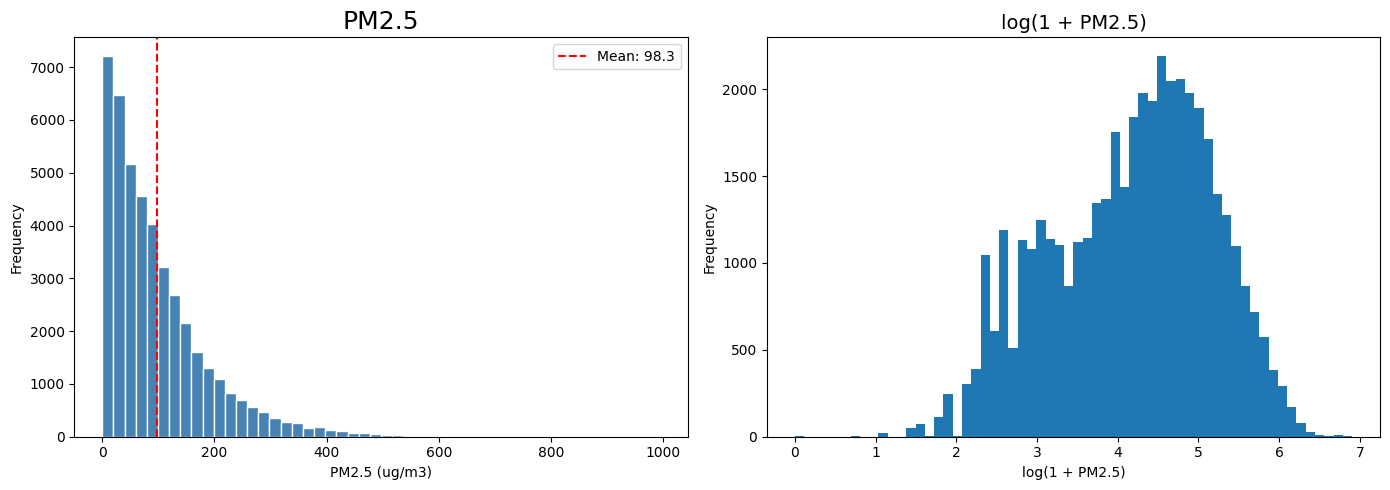

Skewness (raw): 0        129.0
1        129.0
2        129.0
3        129.0
4        129.0
         ...  
43819      8.0
43820     10.0
43821     10.0
43822      8.0
43823     12.0
Name: pm2.5, Length: 43824, dtype: float64


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['pm2.5'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('PM2.5', fontsize=18)
axes[0].set_xlabel('PM2.5 (ug/m3)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['pm2.5'].mean(), color='red', linestyle='--', label=f"Mean: {df['pm2.5'].mean():.1f}")
axes[0].legend()

axes[1].hist(np.log1p(df['pm2.5']), bins=60)
axes[1].set_title('log(1 + PM2.5)', fontsize=14)
axes[1].set_xlabel('log(1 + PM2.5)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Skewness (raw): {df['pm2.5']}")

### Correlation Heatmap

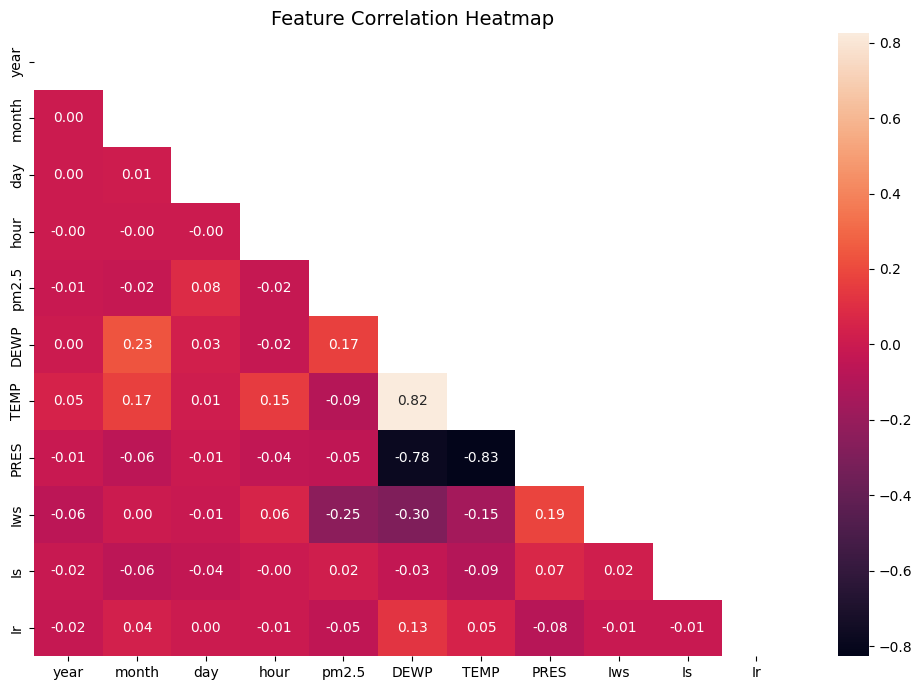

Top correlations with PM2.5
Iws      0.245688
DEWP     0.168500
TEMP     0.089358
day      0.083124
Ir       0.050247
PRES     0.048006
hour     0.023983
month    0.023578
Is       0.019300
year     0.009179


In [59]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask ,annot=True, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print('Top correlations with PM2.5')
print(corr['pm2.5'].drop('pm2.5').abs().sort_values(ascending=False).to_string())
